In [1]:
pip install matplotlib seaborn pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\Abhishek\AppData\Local\Programs\Python\Python38\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("match_analysis.csv")

In [5]:
df["Violation Count"] = df["Violation Count"].astype(int)
df["Shots Made"] = df["Shots Made"].astype(int)
df["Shots Missed"] = df["Shots Missed"].astype(int)
df["Dribbling Efficiency(%)"] = df["Dribbling Efficiency(%)"].astype(int)
df["AI Accuracy(%)"] = df["AI Accuracy(%)"].str.replace("%", "").astype(int)
df["Distance Covered(m)"] = df["Distance Covered(m)"].astype(int)

In [6]:
# Set style
sns.set_theme(style="whitegrid")

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_7660\717380004.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1, 0].set_xticklabels(df["Player Name"], rotation=45)


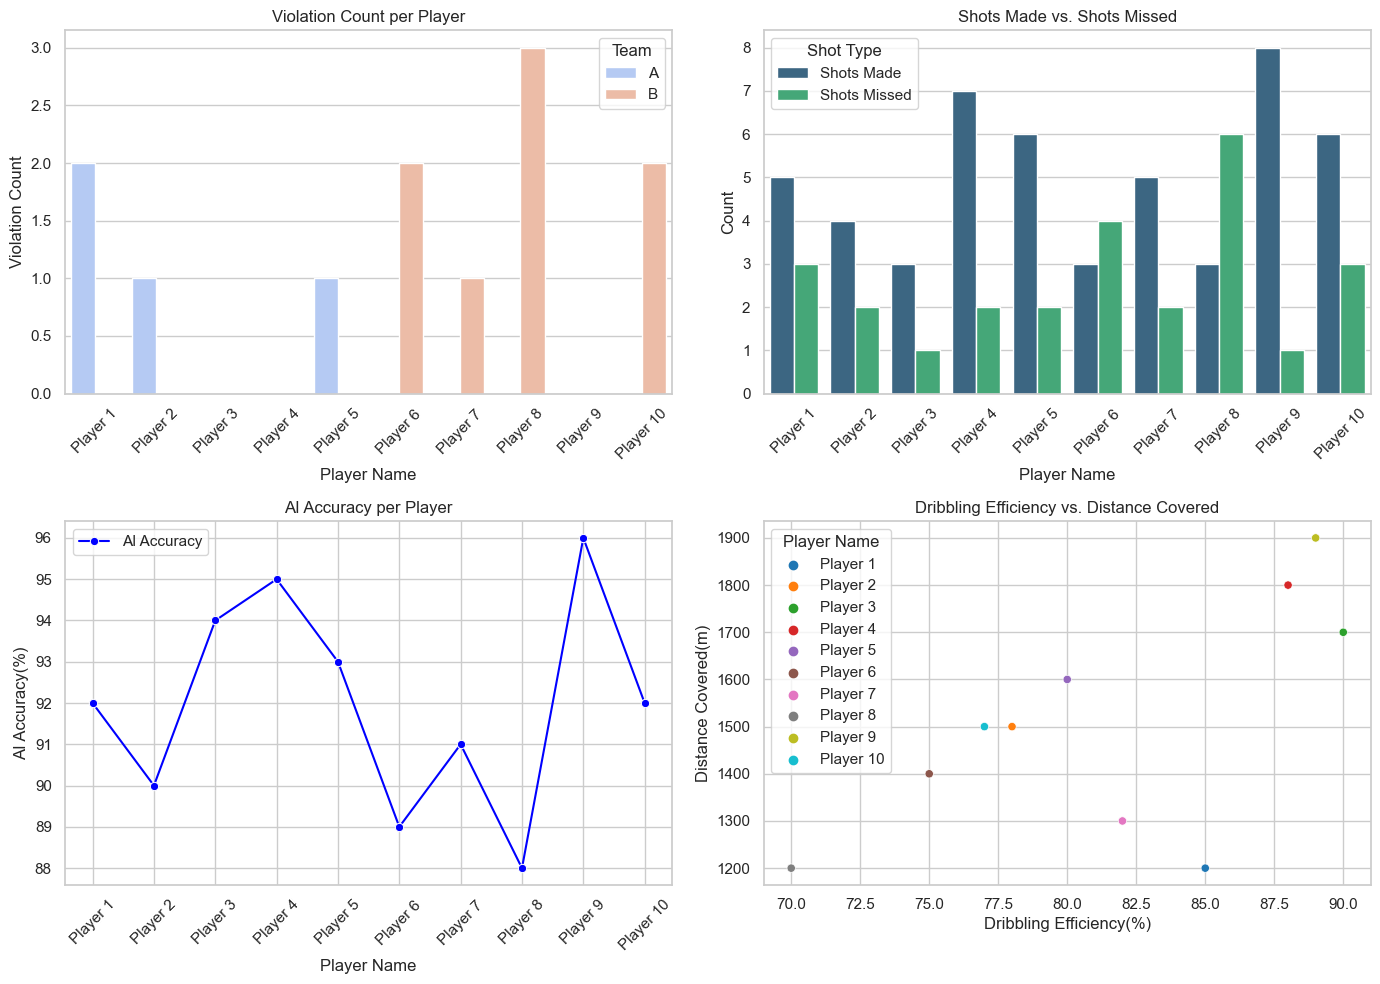

In [11]:
# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bar Chart: Violation Count per Player
sns.barplot(x="Player Name", y="Violation Count", hue="Team", data=df, palette="coolwarm", ax=axes[0, 0])
axes[0, 0].set_title("Violation Count per Player")
axes[0, 0].set_xticklabels(df["Player Name"], rotation=45)

# Clustered Bar Chart: Shots Made vs. Shots Missed
df_shots = df.melt(id_vars=["Player Name", "Team"], value_vars=["Shots Made", "Shots Missed"],
                   var_name="Shot Type", value_name="Count")
sns.barplot(x="Player Name", y="Count", hue="Shot Type", data=df_shots, palette="viridis", ax=axes[0, 1])
axes[0, 1].set_title("Shots Made vs. Shots Missed")
axes[0, 1].set_xticklabels(df["Player Name"], rotation=45)

# Line Chart: AI Accuracy per Player
sns.lineplot(x="Player Name", y="AI Accuracy(%)", marker="o", data=df, ax=axes[1, 0], color="blue", label="AI Accuracy")
axes[1, 0].set_title("AI Accuracy per Player")
axes[1, 0].set_xticklabels(df["Player Name"], rotation=45)

# Scatter Plot: Dribbling Efficiency vs. Distance Covered
sns.scatterplot(x="Dribbling Efficiency(%)", y="Distance Covered(m)", hue="Player Name", data=df, palette="tab10", ax=axes[1, 1])
axes[1, 1].set_title("Dribbling Efficiency vs. Distance Covered")

# Adjust layout and show
plt.tight_layout()
plt.show()